In [1]:
import os
import re
import h5py
import numpy as np
from collections import defaultdict
import spikeinterface.extractors as se

c:\Users\sjs93\anaconda3\envs\biopipeline-env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import sys
import os

# Add your script folder to Python's path
sys.path.append(r"C:\Users\sjs93\OneDrive\Documents\respiratory_pilot\src\file_conversion")

# Import your conversion function
import resp_to_h5_ecu_only as trodes

In [3]:
dir(trodes)


['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'convert_all_rec_to_h5',
 'convert_sessions',
 'h5py',
 'load_trodes_exports',
 'np',
 'os',
 'parse_fields',
 'read_trodes_dat_file',
 'write_h5']

In [4]:
session_dir = r"D:\BLA_ChR_resp\BLA_ChR_resp_RI1_hc_day1\1_1_RI1_f1_d_on_20260111_164638.rec"


In [5]:
analog, dio, time = trodes.load_trodes_exports(session_dir)


In [6]:
print("Analog:", analog.keys())
print("DIO:", dio.keys())
print("Time:", time.keys())


Analog: dict_keys(['1_1_RI1_f1_d_on_20260111_164638.analog_ECU_Ain1', '1_1_RI1_f1_d_on_20260111_164638.timestamps'])
DIO: dict_keys(['1_1_RI1_f1_d_on_20260111_164638.dio_ECU_Din1', '1_1_RI1_f1_d_on_20260111_164638.dio_ECU_Dout1'])
Time: dict_keys(['1_1_RI1_f1_d_on_20260111_164638.timestamps'])


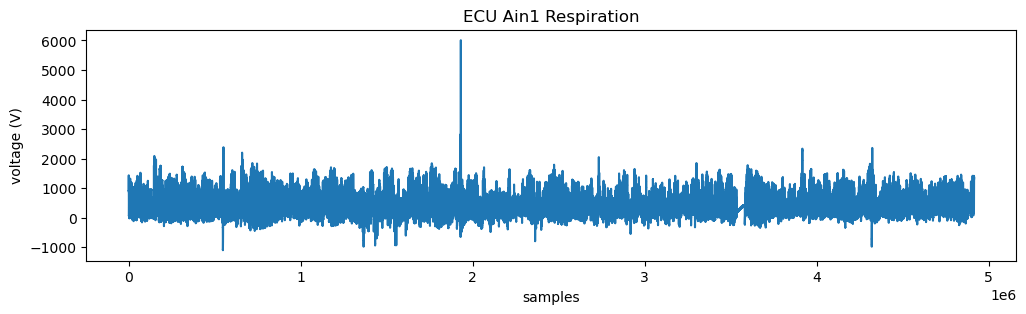

In [7]:
import matplotlib.pyplot as plt

analog_key = [k for k in analog if "Ain1" in k][0]
resp = analog[analog_key]["data"]["voltage"]

plt.figure(figsize=(12, 3))
plt.plot(resp)
plt.title("ECU Ain1 Respiration")
plt.xlabel("samples")
plt.ylabel("voltage (V)")
plt.show()


In [8]:
dio_key = [k for k in dio if "Din1" in k][0]
dio_data = dio[dio_key]["data"]

dio_data.dtype


dtype([('time', '<u4'), ('state', 'u1')])

In [9]:
times = dio_data["time"]
states = dio_data["state"]

on_times = times[states == 1]
off_times = times[states == 0]


In [10]:
out_h5 = r"D:\BLA_ChR_resp\h5\1_1_RI1_f1_d_on_20260111_164638.h5"
trodes.write_h5(out_h5, analog, dio, time)


In [11]:
import os

print(os.path.exists(r"D:\BLA_ChR_resp\h5"))


True


In [12]:
print(os.path.isfile(out_h5))


True


In [13]:
import os

out_dir = r"D:\BLA_ChR_resp\BLA_ChR_resp_RI1_hc_day1\h5_outputs"
os.makedirs(out_dir, exist_ok=True)

out_h5 = os.path.join(
    out_dir,
    "1_1_RI1_f1_d_on_20260111_164638.h5"
)

trodes.write_h5(out_h5, analog, dio, time)

print("Exists:", os.path.exists(out_h5))



Exists: True


In [14]:
data_root = r"D:\BLA_ChR_resp\BLA_ChR_resp_RI1_hc_day1"
output_dir = r"D:\BLA_ChR_resp\BLA_ChR_resp_RI1_hc_day1\h5_outputs"

trodes.convert_sessions(data_root, output_dir)



Processing: 1_1_RI1_f1_d_on_20260111_164638.rec
  Wrote D:\BLA_ChR_resp\BLA_ChR_resp_RI1_hc_day1\h5_outputs\1_1_RI1_f1_d_on_20260111_164638.h5

Processing: 1_2_RI1_f2_f_off_20260109_165330.rec
  Wrote D:\BLA_ChR_resp\BLA_ChR_resp_RI1_hc_day1\h5_outputs\1_2_RI1_f2_f_off_20260109_165330.h5

Processing: 1_3_RI1_f1_c_off_20260110_130254.rec
  Wrote D:\BLA_ChR_resp\BLA_ChR_resp_RI1_hc_day1\h5_outputs\1_3_RI1_f1_c_off_20260110_130254.h5

Processing: 2_1_RI1_f2_h_on_20260110_145355.rec
  Wrote D:\BLA_ChR_resp\BLA_ChR_resp_RI1_hc_day1\h5_outputs\2_1_RI1_f2_h_on_20260110_145355.h5

Processing: 2_2_RI1_f1_b_off_20260109_150435.rec
  Wrote D:\BLA_ChR_resp\BLA_ChR_resp_RI1_hc_day1\h5_outputs\2_2_RI1_f1_b_off_20260109_150435.h5

Processing: 2_3_RI1_f2_f_on_20260110_132734.rec
  Wrote D:\BLA_ChR_resp\BLA_ChR_resp_RI1_hc_day1\h5_outputs\2_3_RI1_f2_f_on_20260110_132734.h5

Processing: 3_1_RI1_f1_b_on_20260111_154618.rec
  Wrote D:\BLA_ChR_resp\BLA_ChR_resp_RI1_hc_day1\h5_outputs\3_1_RI1_f1_b_on_20260

In [15]:
import os

h5_dir = r"D:\BLA_ChR_resp\BLA_ChR_resp_RI1_hc_day1\h5_outputs"

h5_files = sorted([
    os.path.join(h5_dir, f)
    for f in os.listdir(h5_dir)
    if f.endswith(".h5")
])

len(h5_files), h5_files[:3]


(25,
 ['D:\\BLA_ChR_resp\\BLA_ChR_resp_RI1_hc_day1\\h5_outputs\\1_1_RI1_f1_d_on_20260111_164638.h5',
  'D:\\BLA_ChR_resp\\BLA_ChR_resp_RI1_hc_day1\\h5_outputs\\1_2_RI1_f2_f_off_20260109_165330.h5',
  'D:\\BLA_ChR_resp\\BLA_ChR_resp_RI1_hc_day1\\h5_outputs\\1_3_RI1_f1_c_off_20260110_130254.h5'])

In [16]:
import h5py

def load_ecu_h5(h5_path):
    with h5py.File(h5_path, "r") as f:
        analog = {k: f["analog"][k][()] for k in f["analog"].keys()}
        dio    = {k: f["dio"][k][()]    for k in f["dio"].keys()}
        time   = {k: f["time"][k][()]   for k in f["time"].keys()}
    return analog, dio, time


In [17]:
all_sessions = {}

for h5_path in h5_files:
    session_name = os.path.basename(h5_path).replace(".h5", "")
    analog, dio, time = load_ecu_h5(h5_path)

    all_sessions[session_name] = {
        "analog": analog,
        "dio": dio,
        "time": time
    }

print("Loaded sessions:", list(all_sessions.keys()))


Loaded sessions: ['1_1_RI1_f1_d_on_20260111_164638', '1_2_RI1_f2_f_off_20260109_165330', '1_3_RI1_f1_c_off_20260110_130254', '2_1_RI1_f2_h_on_20260110_145355', '2_2_RI1_f1_b_off_20260109_150435', '2_3_RI1_f2_f_on_20260110_132734', '3_1_RI1_f1_b_on_20260111_154618', '3_2_RI1_f1_a_off_20260114_161949', '3_2_RI1_f2_g_off_20260110_122606', '3_3_RI1_f1_c_on_20260111_162426', '4_1_RI1_f2_h_on_20260111_161337', '4_2_RI1_f1_c_off_20260110_150626', '4_3_RI1_f2_e_on_20260111_152801', '5_1_RI1_m1_j_on_20260111_150428', '5_2_RI1_m2_n_off_20260110_135659', '5_3_RI1_m1_k_off_20260109_183135', '6_2_RI1_m1_j_off_20260109_191750', '6_3_RI1_m2_m_off_20260109_174951', '7_1_RI1_m1_k_on_20260111_160052', '7_2_RI1_m2_o_off_20260109_162132', '7_3_RI1_m1_i_on_20260110_142124', '8_1_RI1_m2_m_on_20260110_144121', '8_2_RI1_m1_k_off_20260109_144621', '8_3_RI1_m2_p_on_20260110_134333', '9_1_RI1_m2_m_on_20260111_165857']


In [18]:
for sess, data in all_sessions.items():
    print(sess)
    print("  Analog:", data["analog"].keys())
    print("  DIO:", data["dio"].keys())
    print("  Time:", data["time"].keys())


1_1_RI1_f1_d_on_20260111_164638
  Analog: dict_keys(['1_1_RI1_f1_d_on_20260111_164638.analog_ECU_Ain1', '1_1_RI1_f1_d_on_20260111_164638.timestamps'])
  DIO: dict_keys(['1_1_RI1_f1_d_on_20260111_164638.dio_ECU_Din1', '1_1_RI1_f1_d_on_20260111_164638.dio_ECU_Dout1'])
  Time: dict_keys(['1_1_RI1_f1_d_on_20260111_164638.timestamps'])
1_2_RI1_f2_f_off_20260109_165330
  Analog: dict_keys(['1_2_RI1_f2_f_off_20260109_165330.analog_ECU_Ain1', '1_2_RI1_f2_f_off_20260109_165330.timestamps'])
  DIO: dict_keys(['1_2_RI1_f2_f_off_20260109_165330.dio_ECU_Din1', '1_2_RI1_f2_f_off_20260109_165330.dio_ECU_Dout1'])
  Time: dict_keys(['1_2_RI1_f2_f_off_20260109_165330.timestamps'])
1_3_RI1_f1_c_off_20260110_130254
  Analog: dict_keys(['1_3_RI1_f1_c_off_20260110_130254.analog_ECU_Ain1', '1_3_RI1_f1_c_off_20260110_130254.timestamps'])
  DIO: dict_keys(['1_3_RI1_f1_c_off_20260110_130254.dio_ECU_Din1', '1_3_RI1_f1_c_off_20260110_130254.dio_ECU_Dout1'])
  Time: dict_keys(['1_3_RI1_f1_c_off_20260110_130254.tim

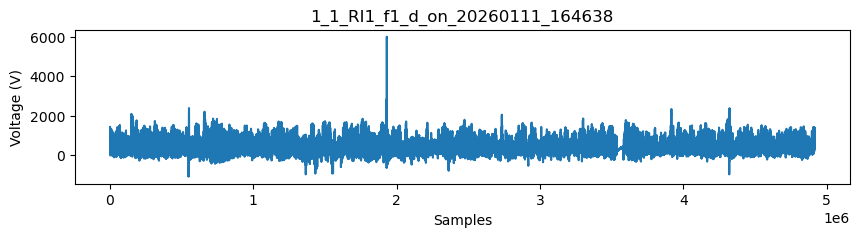

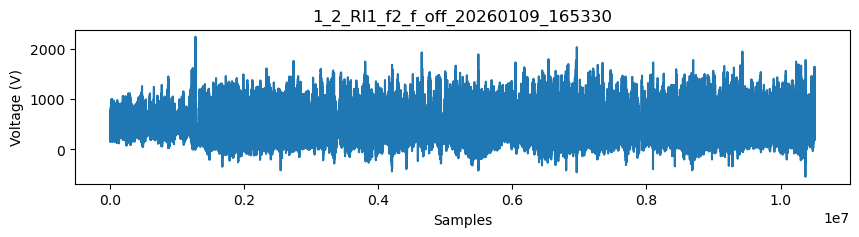

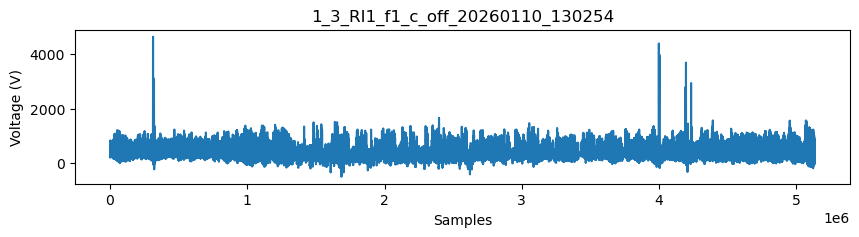

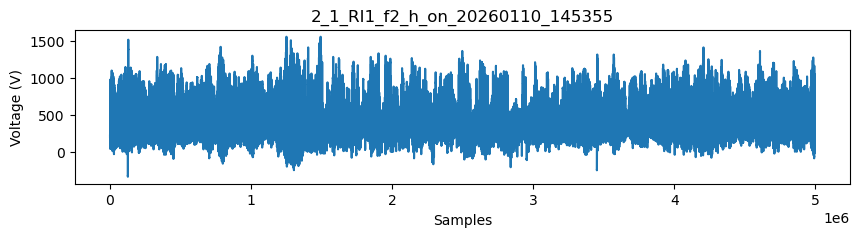

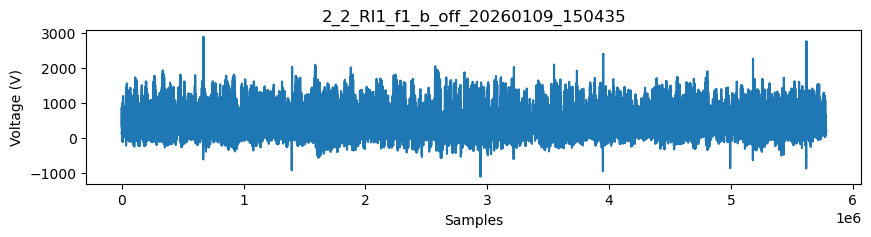

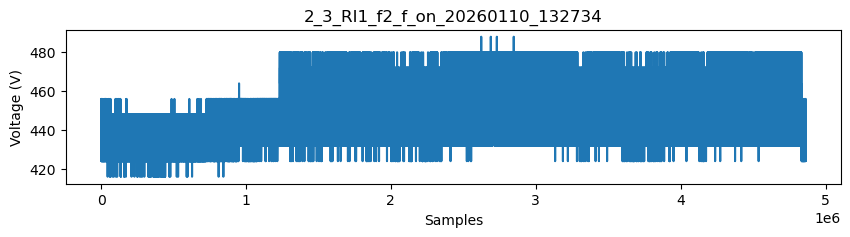

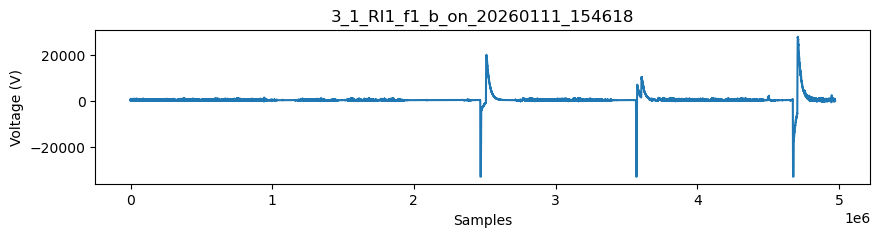

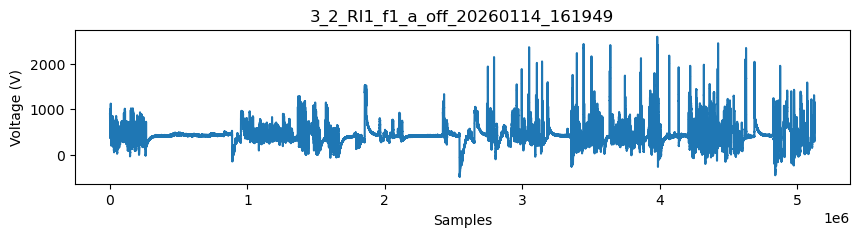

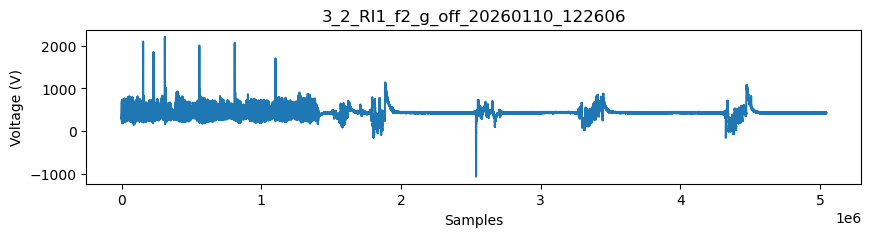

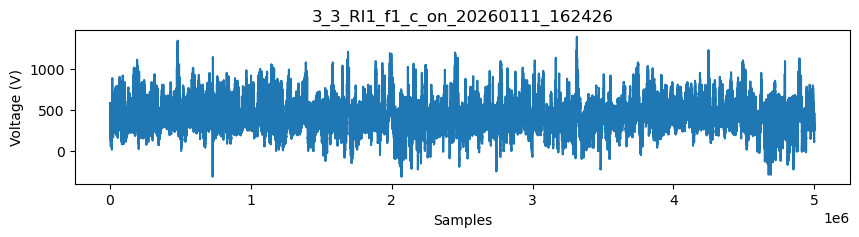

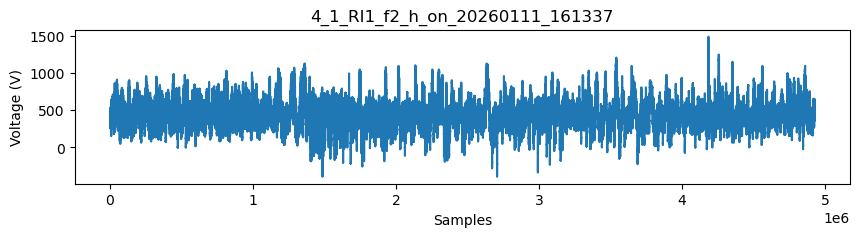

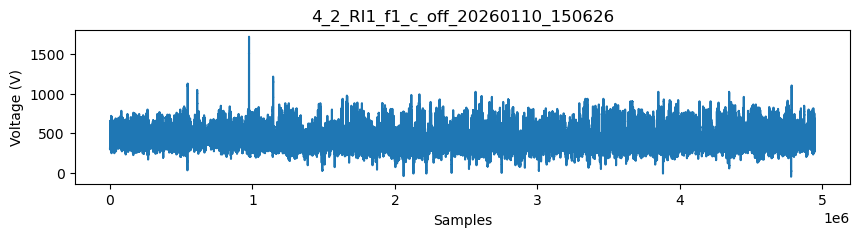

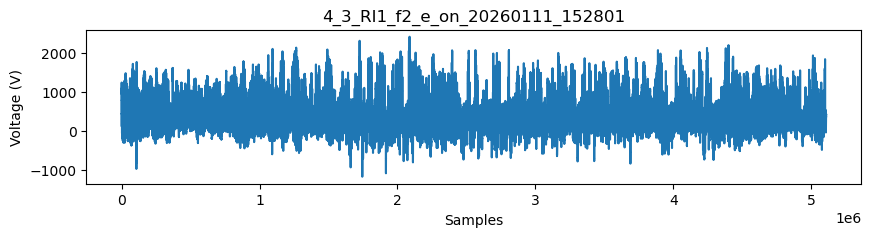

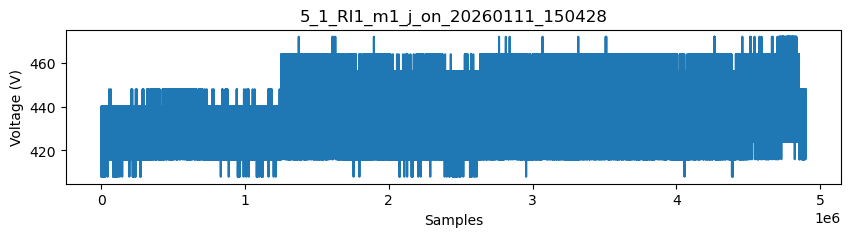

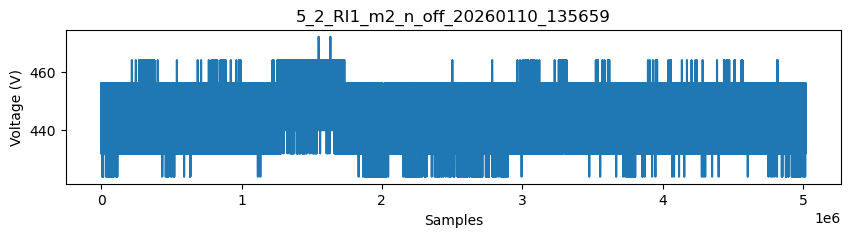

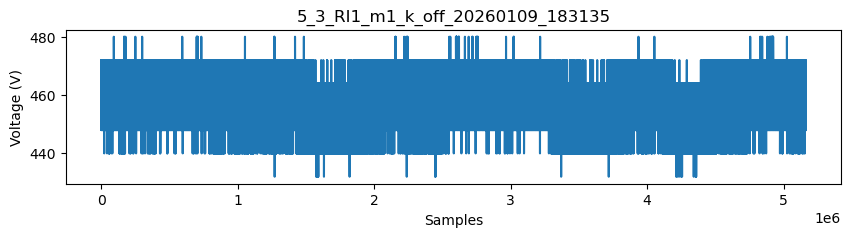

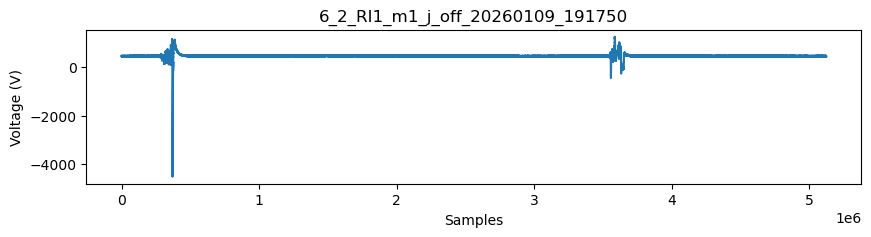

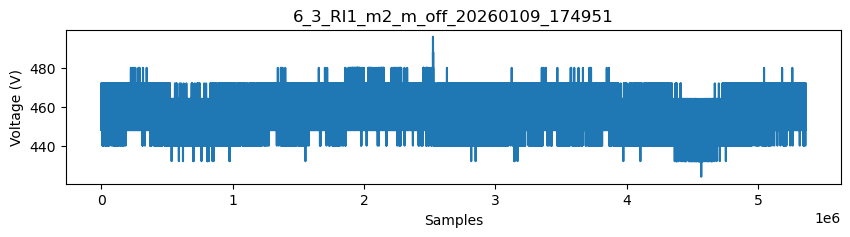

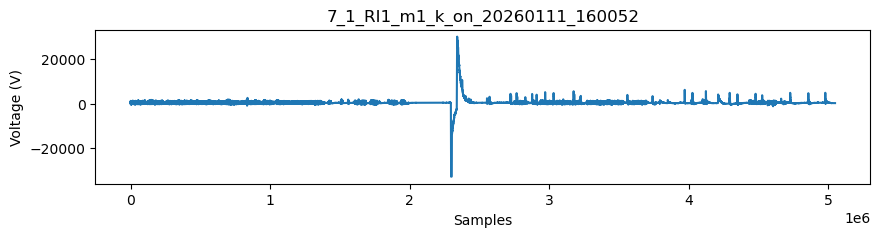

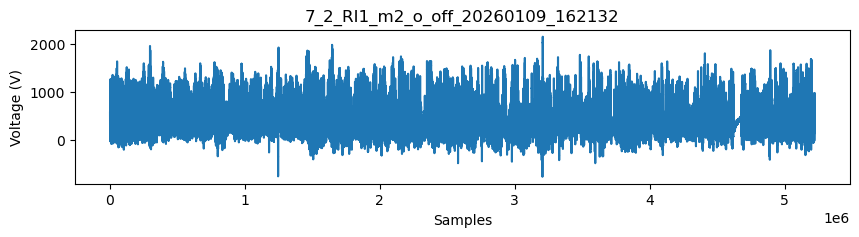

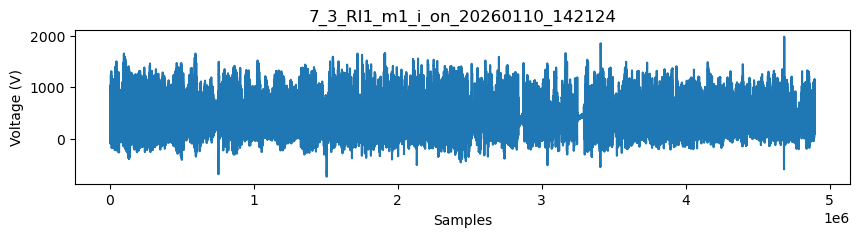

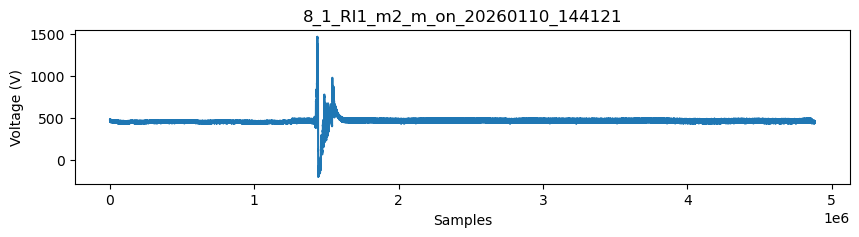

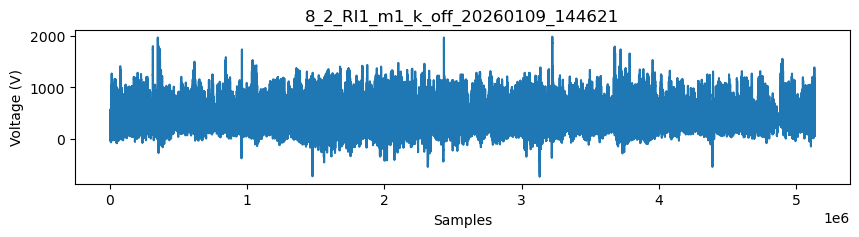

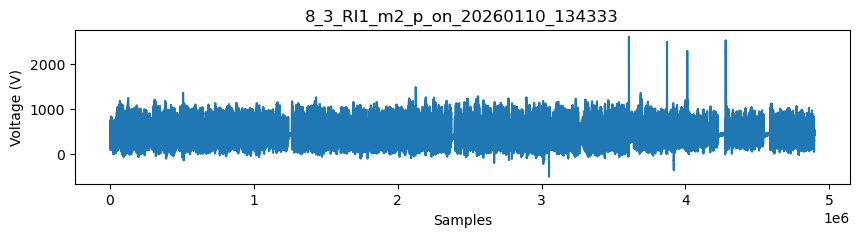

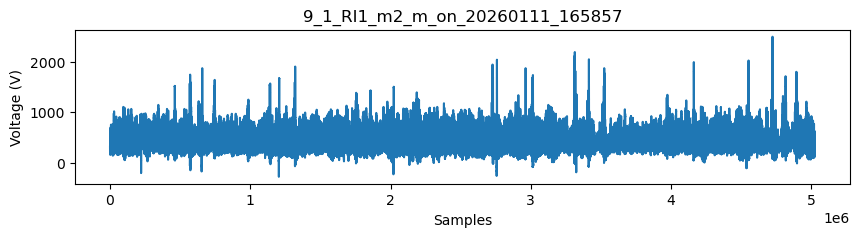

In [19]:
import matplotlib.pyplot as plt

for sess, data in all_sessions.items():
    analog = data["analog"]
    key = [k for k in analog if "Ain1" in k][0]
    resp = analog[key]["voltage"]

    plt.figure(figsize=(10, 2))
    plt.plot(resp)
    plt.title(sess)
    plt.ylabel("Voltage (V)")
    plt.xlabel("Samples")
    plt.show()


In [27]:
import os
import h5py
import numpy as np
from scipy.signal import butter, filtfilt, resample_poly
import neurokit2 as nk


def load_clean_resp_signal_ecu(h5_file, target_rate=100, fs=20000):
    """
    Loads, filters, downsamples respiration from ECU-style .h5.
    Preserves original preprocessing logic.
    
    Returns:
        rsp_cleaned : np.ndarray
        time_vector : np.ndarray
        fs_out      : float (target_rate)
        metadata    : dict
    """

    try:
        with h5py.File(h5_file, 'r') as f:

            # -----------------------------
            # Load respiration (ECU Ain1)
            # -----------------------------
            analog_keys = list(f['analog'].keys())
            resp_keys = [k for k in analog_keys if "Ain1" in k]
            if len(resp_keys) == 0:
                raise RuntimeError("No ECU Ain1 channel found")

            resp_key = resp_keys[0]
            resp = f['analog'][resp_key][()]['voltage'].astype(float)

            # -----------------------------
            # Metadata (keep for compatibility)
            # -----------------------------
            metadata = {
                "fs_original": fs,
                "source": "ECU_Ain1",
                "file": os.path.basename(h5_file)
            }

    except Exception as e:
        print(f"❌ Error loading {os.path.basename(h5_file)}: {e}")
        return None, None, None, None

    # -----------------------------
    # PRE-CLEAN (CRITICAL)
    # -----------------------------
    # Remove NaNs / infs
    bad = ~np.isfinite(resp)
    if np.any(bad):
        resp[bad] = np.nanmedian(resp)

    # Remove DC offset
    resp = resp - np.median(resp)

    # Clip extreme artifacts (opto / motion)
    mad = np.median(np.abs(resp))
    if mad > 0:
        resp = np.clip(resp, -10 * mad, 10 * mad)

    # -----------------------------
    # Low-pass before downsampling
    # -----------------------------
    nyquist = fs / 2
    norm_cutoff = (target_rate / 2) / nyquist
    b, a = butter(N=4, Wn=norm_cutoff, btype='low')
    filtered_resp = filtfilt(b, a, resp)

    # -----------------------------
    # Downsample
    # -----------------------------
    downsample_factor = int(fs // target_rate)
    downsampled = resample_poly(filtered_resp, up=1, down=downsample_factor)

    # -----------------------------
    # Bandpass (NeuroKit)
    # -----------------------------
    rsp_cleaned = nk.signal_filter(
        downsampled,
        lowcut=0.1,
        highcut=20,
        method="butterworth",
        sampling_rate=target_rate,
        order=2
    )

    # -----------------------------
    # Time vector
    # -----------------------------
    time_vector = np.arange(len(rsp_cleaned)) / target_rate

    return rsp_cleaned, time_vector, target_rate, metadata


In [29]:
import os
import h5py
import numpy as np
from scipy.signal import butter, filtfilt, resample


def load_clean_resp_signal_ecu(
    h5_file,
    target_rate=100,
    fs=20000,
    verbose=True
):
    """
    Load respiration signal from ECU-style .h5 file,
    clean, and resample to target_rate.

    Assumes fixed ECU sampling rate = 20 kHz.
    """

    try:
        with h5py.File(h5_file, "r") as f:

            # -----------------------------
            # Find respiration channel
            # -----------------------------
            analog_keys = list(f["analog"].keys())
            resp_keys = [k for k in analog_keys if "Ain1" in k]

            if len(resp_keys) == 0:
                raise RuntimeError("No ECU Ain1 channel found")

            resp_key = resp_keys[0]
            resp_struct = f["analog"][resp_key][()]
            resp = resp_struct["voltage"].astype(float)

        if verbose:
            print(f"[{os.path.basename(h5_file)}]")
            print(f"  fs = {fs} Hz (known)")
            print(f"  n samples = {len(resp)}")

        # -----------------------------
        # Duration
        # -----------------------------
        duration_sec = len(resp) / fs

        # -----------------------------
        # Filter respiration (0.1–15 Hz)
        # -----------------------------
        b, a = butter(4, [0.1, 15.0], btype="bandpass", fs=fs)
        filtered = filtfilt(b, a, resp)

        # -----------------------------
        # Resample to target_rate
        # -----------------------------
        n_out = int(round(duration_sec * target_rate))
        resp_clean = resample(filtered, n_out)
        t = np.arange(n_out) / target_rate

        return resp_clean, t, fs

    except Exception as e:
        print(f"❌ {os.path.basename(h5_file)} failed:")
        print(f"   {e}")
        return None, None, None


In [30]:
resp_clean, t, fs_orig = load_clean_resp_signal_ecu(h5_file)

print("Original fs:", fs_orig)
print("Cleaned length:", len(resp_clean))


[1_1_RI1_f1_d_on_20260111_164638.h5]
  fs = 20000 Hz (known)
  n samples = 4915679
Original fs: 20000
Cleaned length: 24578


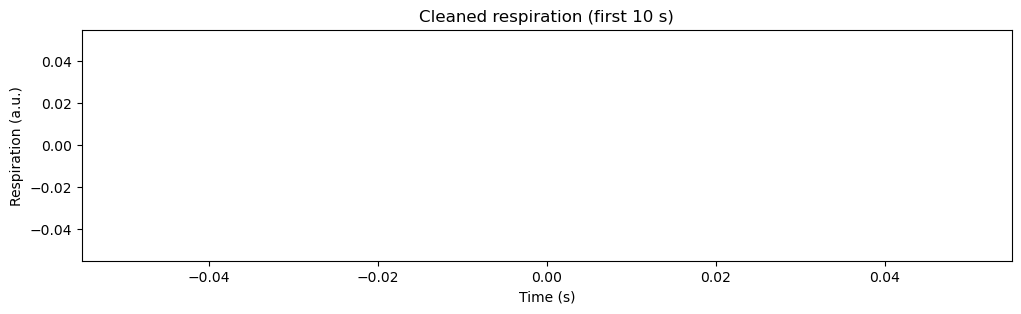

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 3))
plt.plot(t[:1000], resp_clean[:1000])
plt.xlabel("Time (s)")
plt.ylabel("Respiration (a.u.)")
plt.title("Cleaned respiration (first 10 s)")
plt.show()


In [32]:
print("resp_clean:", type(resp_clean), resp_clean.shape)
print("t:", type(t), t.shape)
print("Any NaNs in resp_clean?", np.isnan(resp_clean).any())
print("First 10 resp samples:", resp_clean[:10])
print("First 10 time samples:", t[:10])


resp_clean: <class 'numpy.ndarray'> (24578,)
t: <class 'numpy.ndarray'> (24578,)
Any NaNs in resp_clean? True
First 10 resp samples: [nan nan nan nan nan nan nan nan nan nan]
First 10 time samples: [0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09]


In [33]:
import os
import h5py
import numpy as np
from scipy.signal import butter, filtfilt, resample_poly
import neurokit2 as nk


def load_clean_resp_signal_ecu(h5_file, target_rate=100, fs=20000):
    """
    Loads, filters, downsamples respiration from ECU-style .h5.
    Preserves original preprocessing logic.
    
    Returns:
        rsp_cleaned : np.ndarray
        time_vector : np.ndarray
        fs_out      : float (target_rate)
        metadata    : dict
    """

    try:
        with h5py.File(h5_file, 'r') as f:

            # -----------------------------
            # Load respiration (ECU Ain1)
            # -----------------------------
            analog_keys = list(f['analog'].keys())
            resp_keys = [k for k in analog_keys if "Ain1" in k]
            if len(resp_keys) == 0:
                raise RuntimeError("No ECU Ain1 channel found")

            resp_key = resp_keys[0]
            resp = f['analog'][resp_key][()]['voltage'].astype(float)

            # -----------------------------
            # Metadata (keep for compatibility)
            # -----------------------------
            metadata = {
                "fs_original": fs,
                "source": "ECU_Ain1",
                "file": os.path.basename(h5_file)
            }

    except Exception as e:
        print(f"❌ Error loading {os.path.basename(h5_file)}: {e}")
        return None, None, None, None

    # -----------------------------
    # PRE-CLEAN (CRITICAL)
    # -----------------------------
    # Remove NaNs / infs
    bad = ~np.isfinite(resp)
    if np.any(bad):
        resp[bad] = np.nanmedian(resp)

    # Remove DC offset
    resp = resp - np.median(resp)

    # Clip extreme artifacts (opto / motion)
    mad = np.median(np.abs(resp))
    if mad > 0:
        resp = np.clip(resp, -10 * mad, 10 * mad)

    # -----------------------------
    # Low-pass before downsampling
    # -----------------------------
    nyquist = fs / 2
    norm_cutoff = (target_rate / 2) / nyquist
    b, a = butter(N=4, Wn=norm_cutoff, btype='low')
    filtered_resp = filtfilt(b, a, resp)

    # -----------------------------
    # Downsample
    # -----------------------------
    downsample_factor = int(fs // target_rate)
    downsampled = resample_poly(filtered_resp, up=1, down=downsample_factor)

    # -----------------------------
    # Bandpass (NeuroKit)
    # -----------------------------
    rsp_cleaned = nk.signal_filter(
        downsampled,
        lowcut=0.1,
        highcut=20,
        method="butterworth",
        sampling_rate=target_rate,
        order=2
    )

    # -----------------------------
    # Time vector
    # -----------------------------
    time_vector = np.arange(len(rsp_cleaned)) / target_rate

    return rsp_cleaned, time_vector, target_rate, metadata


In [34]:
rsp, t, fs_out, meta = load_clean_resp_signal_ecu(h5_file)

print(rsp.shape, fs_out)


(24579,) 100


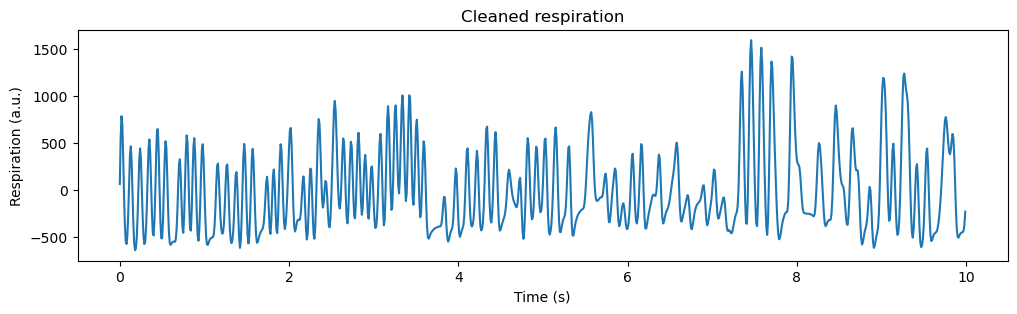

In [35]:
plt.figure(figsize=(12,3))
plt.plot(t[:1000], rsp[:1000])
plt.xlabel("Time (s)")
plt.ylabel("Respiration (a.u.)")
plt.title("Cleaned respiration")
plt.show()


In [36]:
import numpy as np
from scipy.signal import find_peaks


def get_sniff_respiratory_rate(
    signal,
    time,
    sniff_start,
    sniff_end,
    sampling_rate=100,
    max_rate_hz=12
):
    """
    Compute average respiration/sniff rate using inter-breath intervals (IBI).
    
    Returns:
        avg_rate_hz (float) or np.nan
    """

    # -----------------------------
    # Mask window
    # -----------------------------
    sniff_mask = (time >= sniff_start) & (time < sniff_end)

    if sniff_mask.sum() < sampling_rate:  # <1 s of data
        return np.nan

    signal_sniff = signal[sniff_mask]
    time_sniff = time[sniff_mask]

    # -----------------------------
    # Pre-clean for peak detection
    # -----------------------------
    signal_sniff = signal_sniff - np.mean(signal_sniff)

    # -----------------------------
    # Peak detection
    # -----------------------------
    min_ibi = 1.0 / max_rate_hz
    min_distance = int(min_ibi * sampling_rate)

    peaks, _ = find_peaks(
        signal_sniff,
        distance=min_distance
    )

    if len(peaks) < 2:
        return np.nan

    # -----------------------------
    # IBI and rate
    # -----------------------------
    peak_times = time_sniff[peaks]
    ibi = np.diff(peak_times)          # seconds
    inst_rate = 1.0 / ibi              # Hz

    return np.mean(inst_rate)


In [39]:
print("Session:", os.path.basename(h5_file))


Session: 1_1_RI1_f1_d_on_20260111_164638.h5


In [40]:
rsp, t, fs_out, meta = load_clean_resp_signal_ecu(h5_file)

rate = get_sniff_respiratory_rate(
    signal=rsp,
    time=t,
    sniff_start=10,
    sniff_end=20,
    sampling_rate=fs_out
)

print("Respiration rate (Hz):", rate)
print("Respiration rate (breaths/min):", rate * 60)


Respiration rate (Hz): 10.137794253748195
Respiration rate (breaths/min): 608.2676552248918


In [41]:
h5_files

['D:\\BLA_ChR_resp\\BLA_ChR_resp_RI1_hc_day1\\h5_outputs\\1_1_RI1_f1_d_on_20260111_164638.h5',
 'D:\\BLA_ChR_resp\\BLA_ChR_resp_RI1_hc_day1\\h5_outputs\\1_2_RI1_f2_f_off_20260109_165330.h5',
 'D:\\BLA_ChR_resp\\BLA_ChR_resp_RI1_hc_day1\\h5_outputs\\1_3_RI1_f1_c_off_20260110_130254.h5',
 'D:\\BLA_ChR_resp\\BLA_ChR_resp_RI1_hc_day1\\h5_outputs\\2_1_RI1_f2_h_on_20260110_145355.h5',
 'D:\\BLA_ChR_resp\\BLA_ChR_resp_RI1_hc_day1\\h5_outputs\\2_2_RI1_f1_b_off_20260109_150435.h5',
 'D:\\BLA_ChR_resp\\BLA_ChR_resp_RI1_hc_day1\\h5_outputs\\2_3_RI1_f2_f_on_20260110_132734.h5',
 'D:\\BLA_ChR_resp\\BLA_ChR_resp_RI1_hc_day1\\h5_outputs\\3_1_RI1_f1_b_on_20260111_154618.h5',
 'D:\\BLA_ChR_resp\\BLA_ChR_resp_RI1_hc_day1\\h5_outputs\\3_2_RI1_f1_a_off_20260114_161949.h5',
 'D:\\BLA_ChR_resp\\BLA_ChR_resp_RI1_hc_day1\\h5_outputs\\3_2_RI1_f2_g_off_20260110_122606.h5',
 'D:\\BLA_ChR_resp\\BLA_ChR_resp_RI1_hc_day1\\h5_outputs\\3_3_RI1_f1_c_on_20260111_162426.h5',
 'D:\\BLA_ChR_resp\\BLA_ChR_resp_RI1_hc_day1\